In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzA2LWNpcmN1aXRvcy1lbWFyYW5oYW1lbnRv'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from qiskit.quantum_info import Statevector

Estado inicial: |00⟩
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

Circuito inicial:


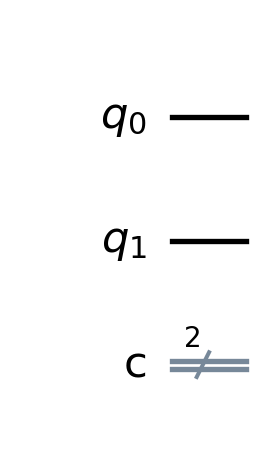

In [3]:
# 1. CONSTRUÇÃO DO CIRCUITO
# Criamos um circuito com 2 Qubits e 2 Bits Clássicos (para guardar o resultado)
qc = QuantumCircuit(2, 2)

# Visualizar estado inicial
estado_inicial = Statevector.from_instruction(qc)
print("Estado inicial: |00⟩")
print(estado_inicial)

# Desenha o circuito
print("\nCircuito inicial:")
qc.draw('mpl')

# É uma boa prática para quem está aprendendo sempre desenhar o circuito após cada modificação.

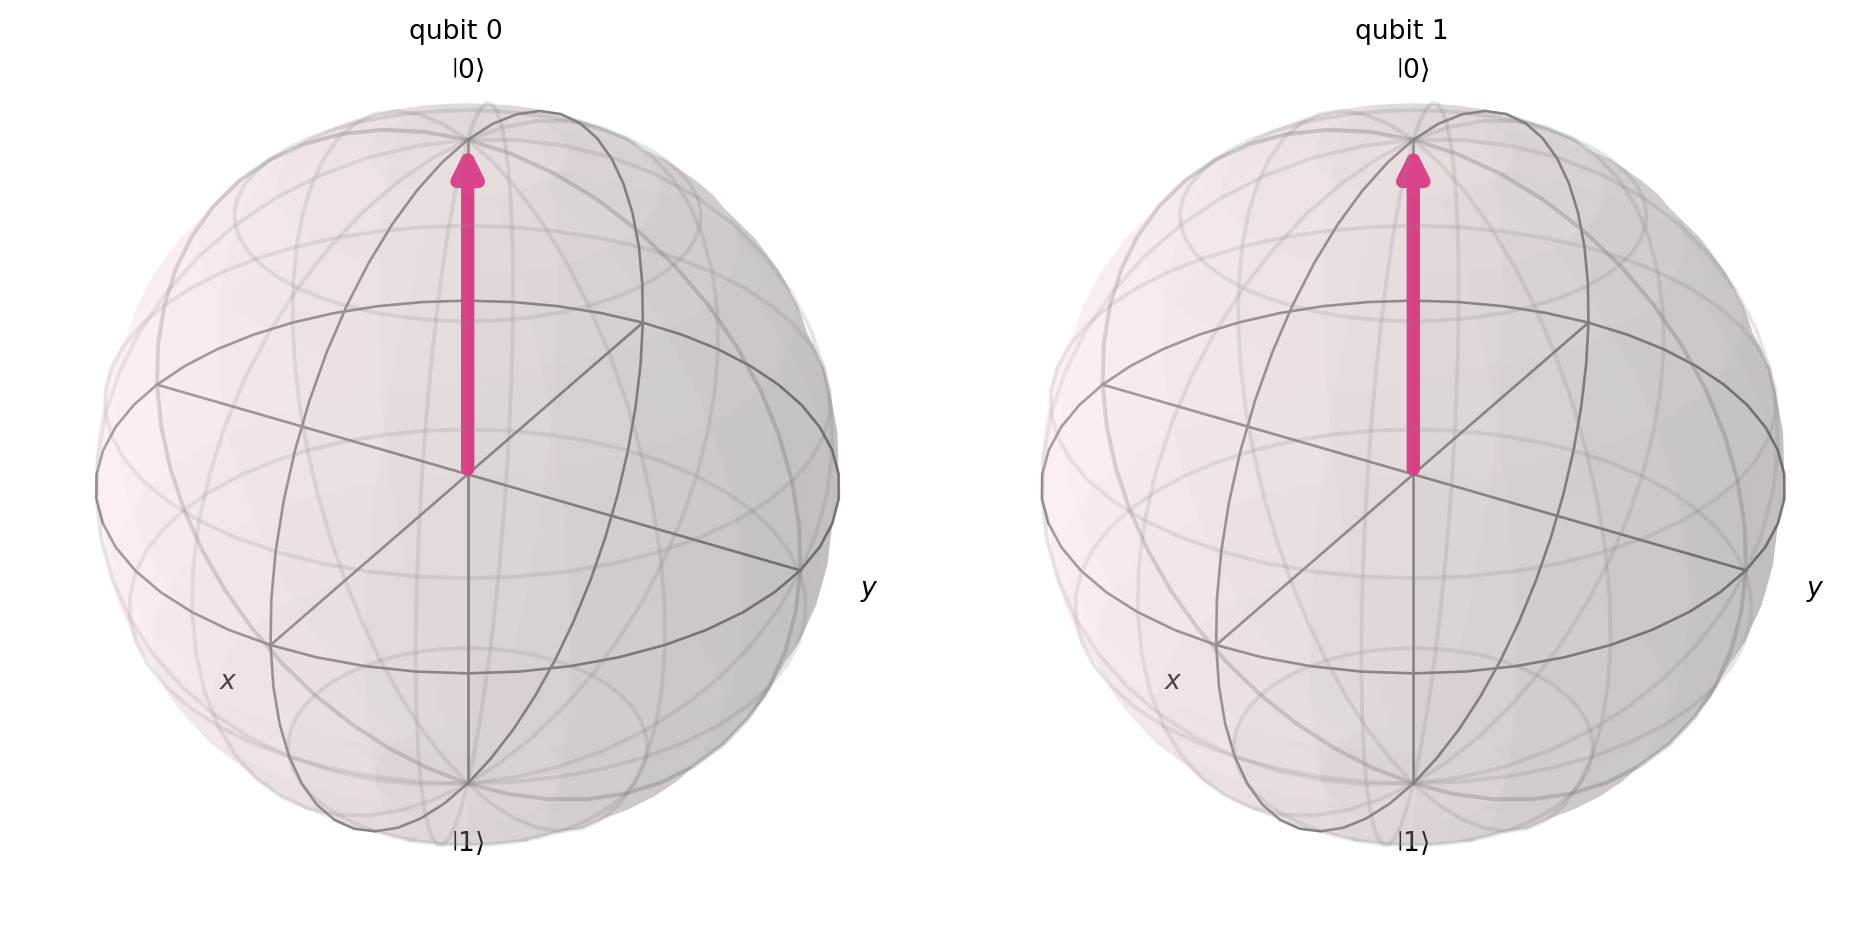

In [4]:
# Esfera de Bloch - Estado inicial
plot_bloch_multivector(estado_inicial)

Estado após H: 1/√2(|00⟩ + |10⟩)
Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))


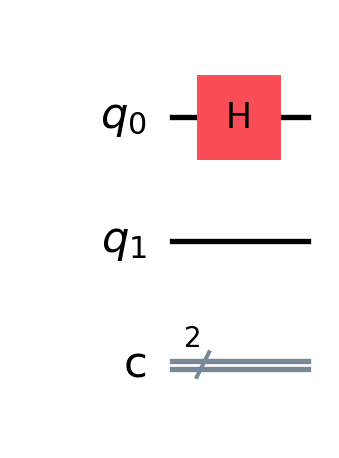

In [5]:
# Aplicamos a porta Hadamard (H) no qubit 0
# Matematicamente: Leva |0> para uma superposição (50% 0, 50% 1)
qc.h(0)

# Visualizar estado após Hadamard
estado_apos_h = Statevector.from_instruction(qc)
print("Estado após H: 1/√2(|00⟩ + |10⟩)")
print(estado_apos_h)
qc.draw('mpl')

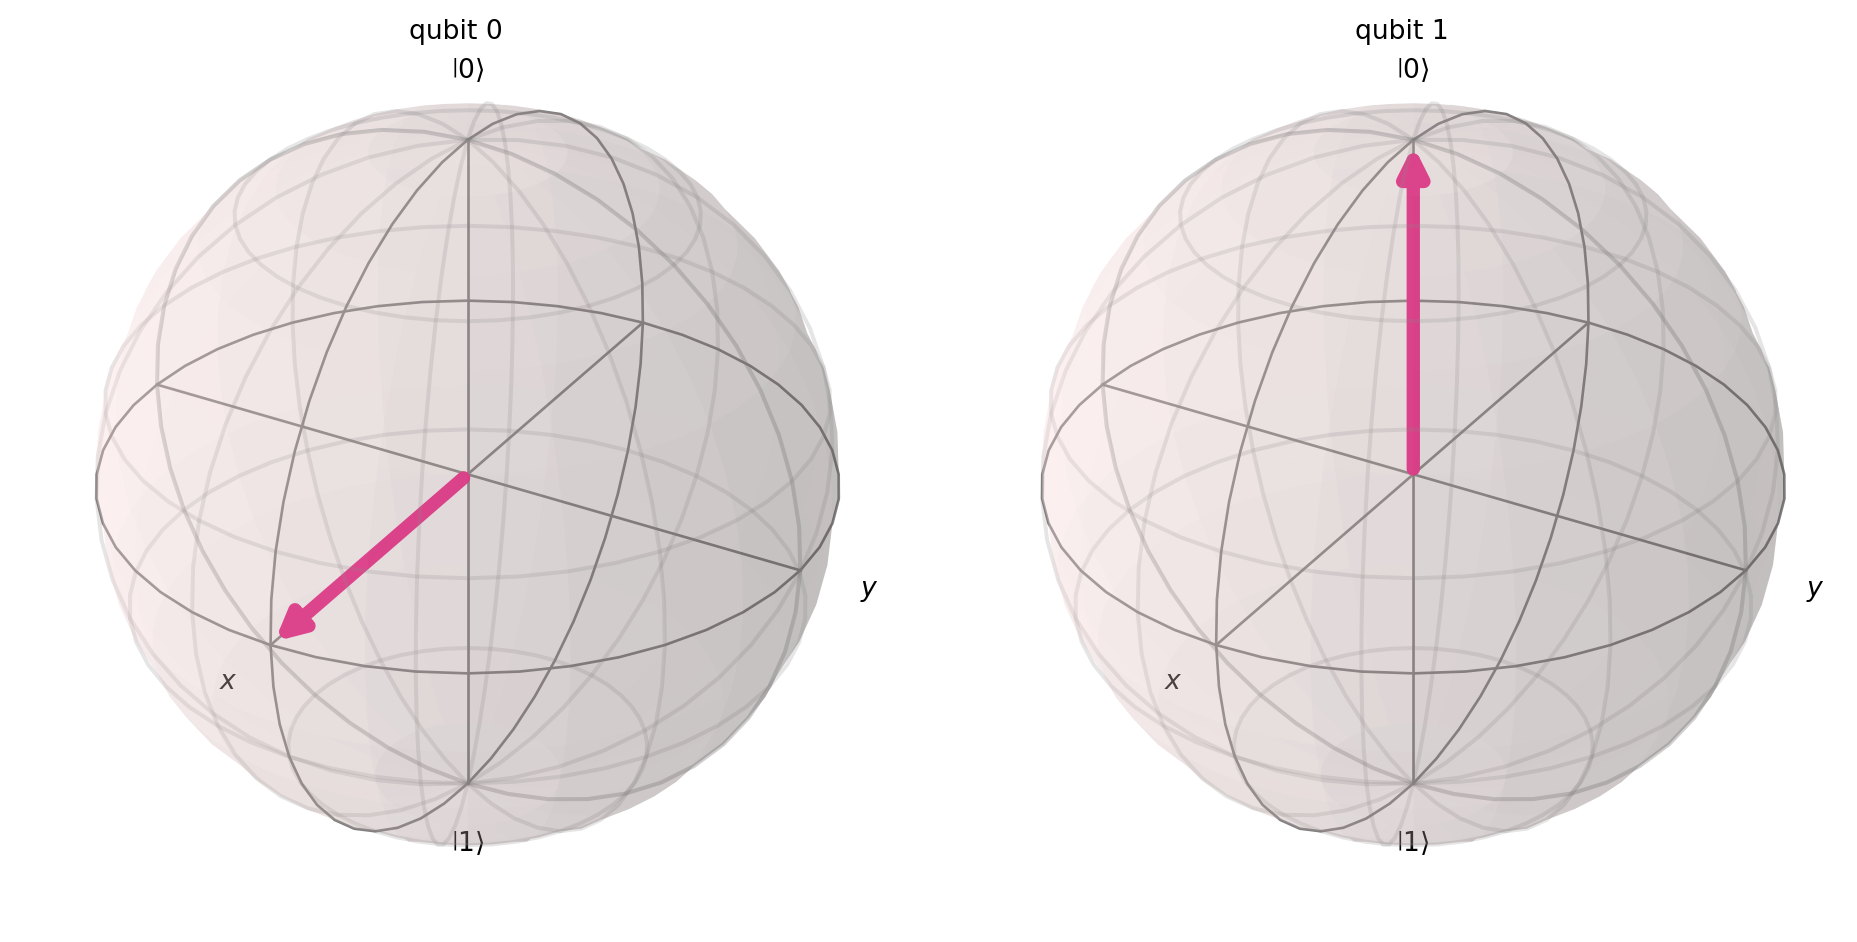

In [6]:
# Esfera de Bloch - Após Hadamard
plot_bloch_multivector(estado_apos_h)

# Veja que somente aplicamos a porta H no qubit 0, o qubit 1 permanece em |0⟩.

Estado após CNOT: 1/√2(|00⟩ + |11⟩) - Estado de Bell |Φ+⟩
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


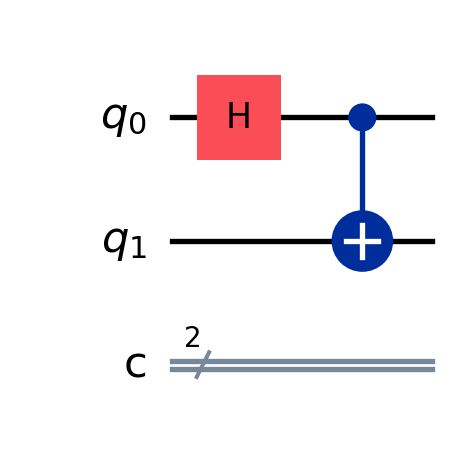

In [7]:
# Aplicamos a porta CNOT (Control-NOT)
# O Qubit 0 é o controle, o Qubit 1 é o alvo.
# Se o Qubit 0 for 1, ele inverte o Qubit 1.
# Como o Qubit 0 está em superposição, eles ficam EMARANHADOS.
qc.cx(0, 1)

# Visualizar estado após CNOT (Estado de Bell)
estado_apos_cnot = Statevector.from_instruction(qc)
print("Estado após CNOT: 1/√2(|00⟩ + |11⟩) - Estado de Bell |Φ+⟩")
print(estado_apos_cnot)
qc.draw('mpl')


🌐 Q-Sphere - Mostra todas as amplitudes do estado emaranhado:


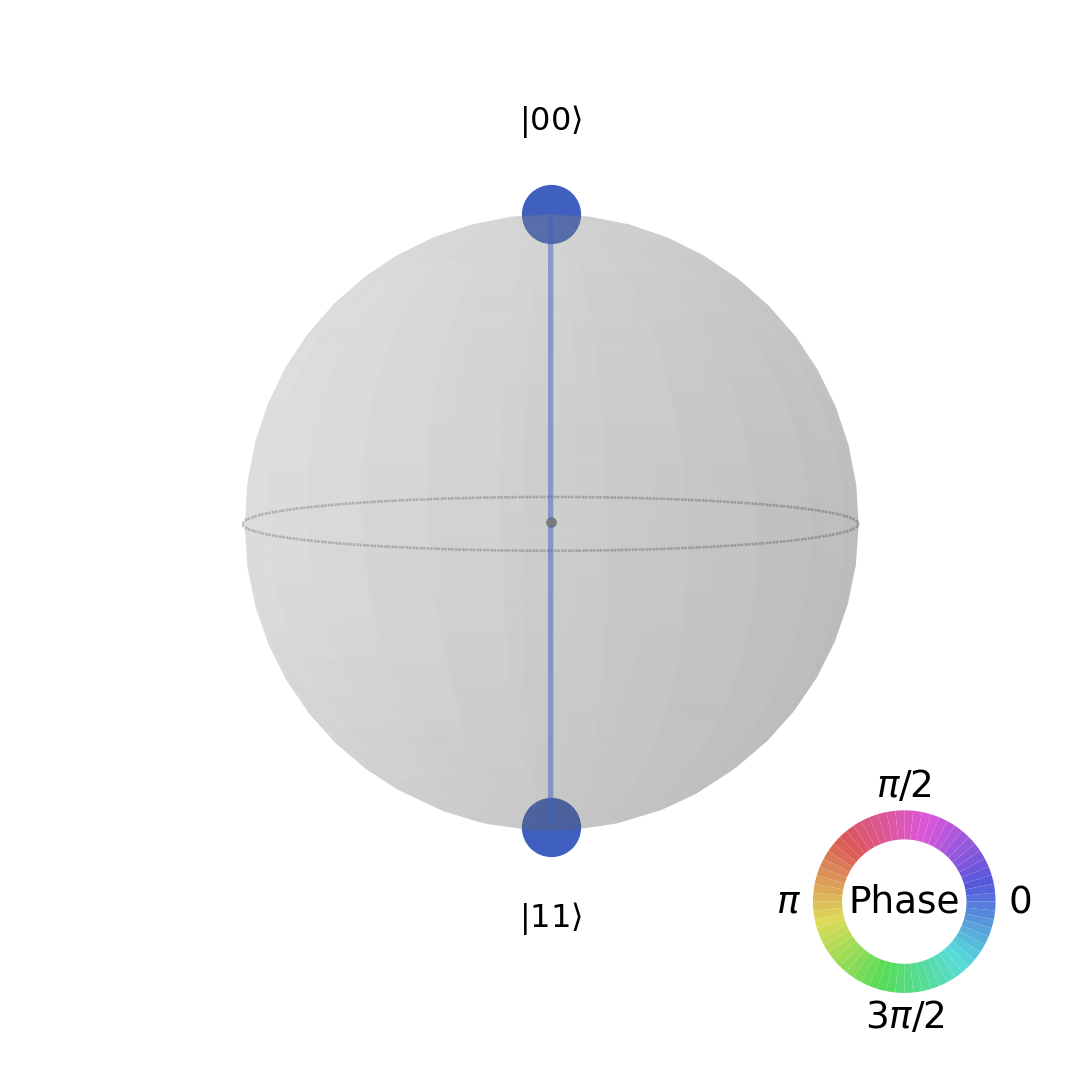

In [8]:
# Q-Sphere - Melhor para visualizar o estado emaranhado completo
print("\n🌐 Q-Sphere - Mostra todas as amplitudes do estado emaranhado:")
plot_state_qsphere(estado_apos_cnot)

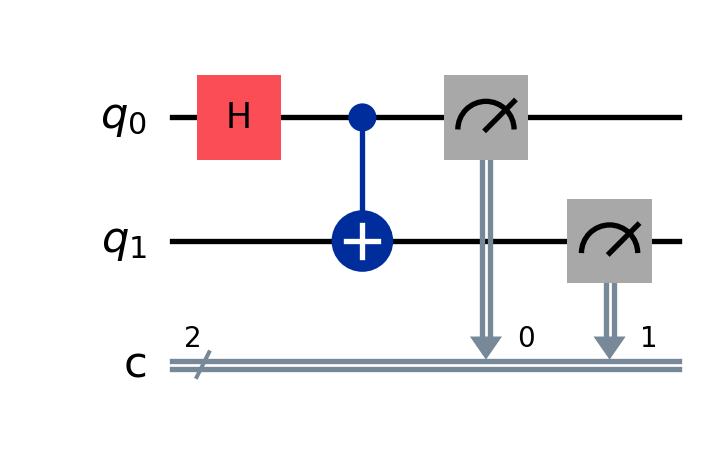

In [9]:
# Medimos os qubits
# Qubit 0 -> guarda no Bit 0
# Qubit 1 -> guarda no Bit 1
qc.measure([0, 1], [0, 1])

# Desenhar circuito completo
qc.draw('mpl')

In [10]:
# 2. EXECUÇÃO (SIMULAÇÃO)
simulador = AerSimulator()

# Transpilação: otimiza o circuito para o backend específico (neste caso, o simulador)
circuito_compilado = transpile(qc, simulador)

# Rodamos a simulação 1000 vezes (shots)
job = simulador.run(circuito_compilado, shots=1000)

# 3. ANÁLISE DE RESULTADOS
resultado = job.result()
contagens = resultado.get_counts()

print("\n--- Resultados da Medição (1000 execuções) ---")
print(contagens)


--- Resultados da Medição (1000 execuções) ---
{'00': 508, '11': 492}


Gerando imagem do Estado Zero (Pólo Norte)...


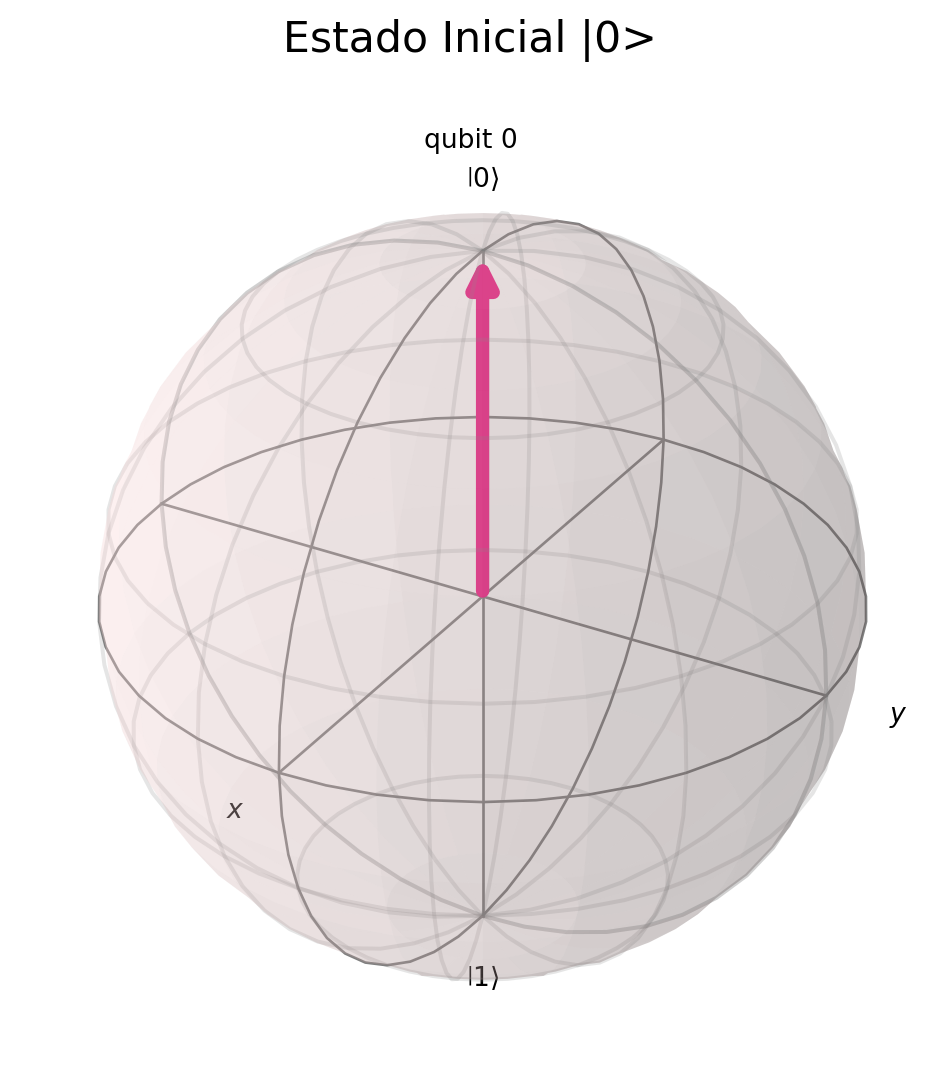

In [11]:
%matplotlib inline

# --- 1. Estado Inicial (|0>) ---
# Um circuito vazio começa sempre em zero
qc_zero = QuantumCircuit(1)

# Extraímos o estado matemático (vetor)
estado_zero = Statevector(qc_zero)

print("Gerando imagem do Estado Zero (Pólo Norte)...")

# Nota: plot_bloch_multivector retorna uma figura matplotlib
fig1 = plot_bloch_multivector(estado_zero, title="Estado Inicial |0>")

Gerando imagem da Superposição (Equador)...


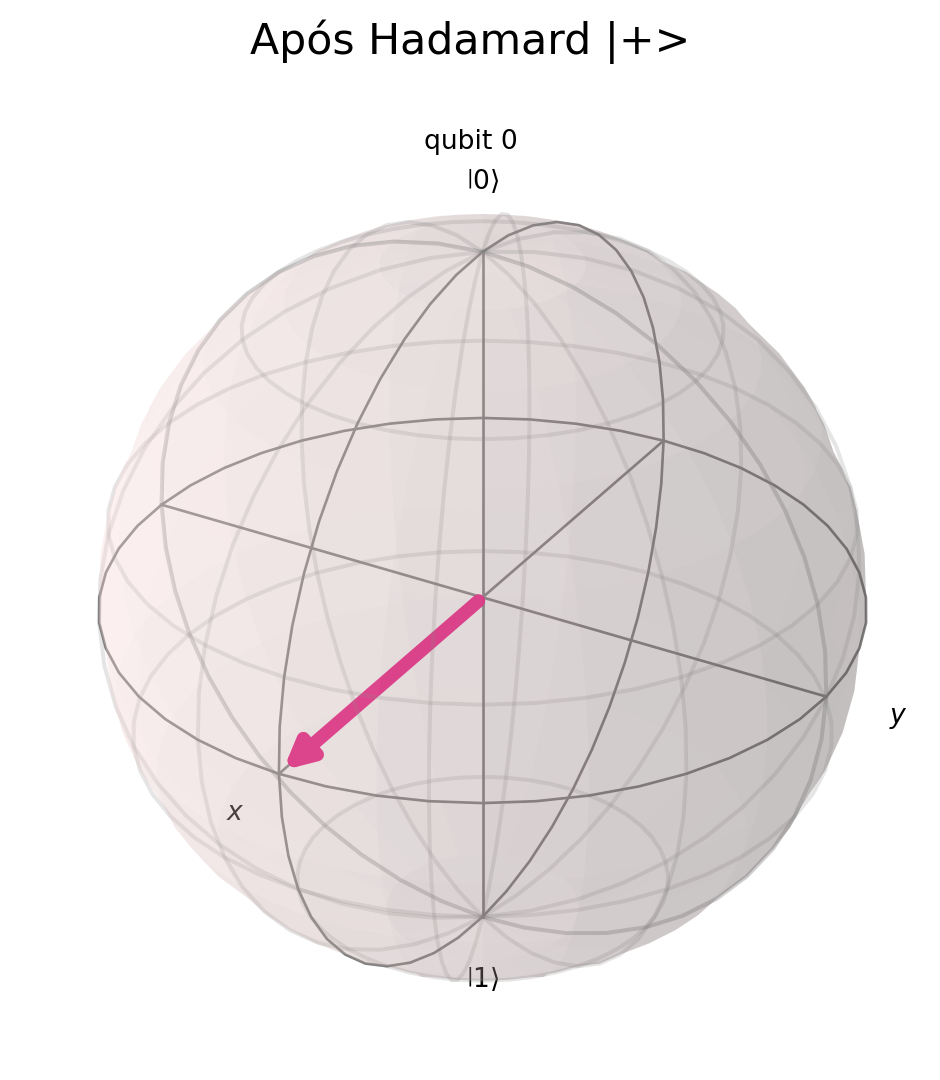

In [12]:
# --- 2. Estado de Superposição (Apicando Hadamard) ---
qc_super = QuantumCircuit(1)
qc_super.h(0) # Aplica H
# qc_super.z(0) # Aplica Z para mostrar diferença de fase
estado_super = Statevector(qc_super)

print("Gerando imagem da Superposição (Equador)...")
fig2 = plot_bloch_multivector(estado_super, title="Após Hadamard |+>")

Gerando imagem do Estado Invertido (Pólo Sul)...


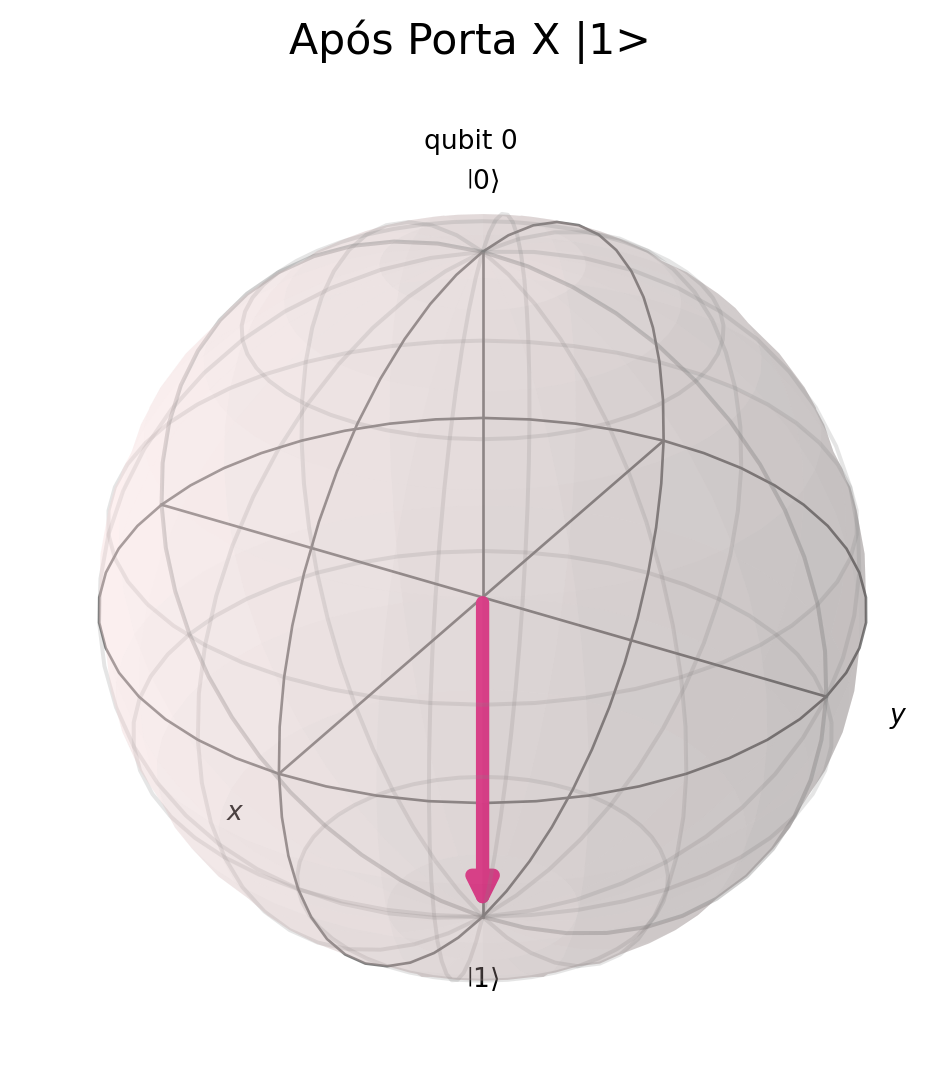

In [13]:
# --- 3. Estado Invertido (Aplicando X) ---
qc_inv = QuantumCircuit(1)
qc_inv.x(0) # Aplica X
estado_inv = Statevector(qc_inv)

print("Gerando imagem do Estado Invertido (Pólo Sul)...")
fig3 = plot_bloch_multivector(estado_inv, title="Após Porta X |1>")